In [60]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [61]:
import torch #Library
import torch.nn as nn #Neural Netwrok Class
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader #A whole Class by itself, with multiple function
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [62]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [63]:
data_df.dropna(inplace = True) #Here we are droping null values and the id column, because its irrelevent.
data_df.drop(['id'], axis = 1, inplace = True)
print(data_df.shape)

(18185, 11)


In [64]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [65]:
print(data_df['Class'].unique())

[1 0]


In [66]:
print(data_df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [67]:
#preprocessing. Here we are normalizing because the values are extremely huge, Usually we want values to be small beacuse the weights of the NN are relatively small compared to these values.
# Normalize=The maximum value of each column will be 1. We are going to take the values in each column and divide it by the largest value in that column.
original_df = data_df.copy()#We will need the original values for the inference
for column in data_df.columns:#we are going through each column inside the dataset, and taking
  data_df[column] = data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [68]:
# Here we are spliting the dataset
X = np.array(data_df.iloc[:, :-1])# Here we are taking all the columns, and all the columns except the last one.
Y = np.array(data_df.iloc[:, -1])# Here we are talking all the columns, and only the last one.

In [69]:
#Here we are spliting the dataset into training(for the model to learn), validating(validation of the model during training, monitor its progress) and testing

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3) #70% split. We are spliting the data into training 70% and testing 70%

In [70]:
#Here we are going to do the same for validation
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5)# The aim of this split is to have 70% training, 15% testing, 15% validation

In [71]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [72]:
#Here we will be creating a dataset object. we create a class called dataset and that inherits the dataset object that we imprtorted above
# We will take the functions inside thhe class and overwrite or modify some of the functions to match the properties of our data
class dataset(Dataset):
  def __init__(self, X, Y):#Here we are defining our constructor that takes self, the inputs X and outputs Y
    self.X = torch.tensor(X, dtype = torch.float32).to(device)#Here we define self.X, which means the x or input value of that dataset object, will be the x that we get from the constructor, which can be a array/list, so it need to be converted to torch.tensor(list/vector/matrix). torch understands tensors. this is a 1 dimension vector. we move the list to device(GPU-cuda)
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

  #here we have 2 functions we need to modify from the dataset object. These functioned will be used inside the training and how the model will be training

  def __len__(self):#returns the shape of the input
    return len(self.X)

  def __getitem__(self, index):# Here we are getting a specific item according to the index
    return self.X[index], self.Y[index]


In [73]:
#Here we are creating objects(dataset object) for training validation and testing.
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [74]:
#Here we are creating 3 data loaders for the data just above. A Dataloadeer is a utility that acts as an iterable over a dataset, efficiently loading data in mini-batches, shuffling it at each epoch, and using multiprocessing for faster data retrieval
training_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = 32, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size = 32, shuffle = True)

In [75]:
for x, y in training_dataloader: #here we are looping through the dataloader. It loops through 8 data rows at once. x=input, y=output
  print(x)
  print("======")
  print(y)
  break

tensor([[0.5303, 0.7911, 0.5855, 0.9752, 0.5033, 0.7282, 0.5318, 0.6325, 0.7268,
         0.7667],
        [0.6111, 0.8049, 0.6588, 0.9615, 0.5821, 0.7817, 0.7866, 0.6635, 0.7613,
         0.6932],
        [0.6420, 0.8984, 0.6281, 0.9817, 0.6130, 0.8013, 0.8057, 0.7132, 0.6921,
         0.8115],
        [0.9000, 0.9146, 0.8499, 0.9393, 0.8490, 0.9487, 0.8657, 0.7641, 0.8454,
         0.6105],
        [0.6723, 0.9352, 0.6315, 0.9853, 0.6363, 0.8199, 0.8429, 0.7377, 0.6774,
         0.8401],
        [0.7683, 0.7992, 0.8345, 0.9127, 0.7267, 0.8765, 0.7707, 0.6908, 0.8828,
         0.5434],
        [0.6683, 0.9172, 0.6418, 0.9816, 0.6360, 0.8175, 0.5325, 0.7305, 0.6868,
         0.8108],
        [0.9053, 0.9129, 0.8625, 0.9360, 0.8588, 0.9515, 0.6552, 0.7705, 0.8364,
         0.6005],
        [0.8382, 0.8563, 0.8513, 0.9248, 0.8040, 0.9155, 0.7884, 0.7504, 0.8164,
         0.5706],
        [0.9548, 0.8832, 0.9424, 0.9070, 0.9112, 0.9771, 0.8645, 0.7792, 0.8623,
         0.5317],
        [0

In [76]:
#Here are building our own model the same way we built our custom dataset. We have a model and we will be doing the inheritance of the model.
HIDDEN_NEURONS = 10 #The output features
class MyModel(nn.Module):#MyModel inherits from my nn.module, taking all the functions and properties in nn.modules.
  def __init__(self):#Here we are modifying the constructor and the forward function
    super(MyModel, self).__init__()#Here we will use the same constructor of the nn module by using super

    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)#Here we are creating the layers. an input layer is a normal linear layer
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)#This is a normal multi-layer preceptron layer(The Hidden Layer). its output is 1
    self.sigmoid = nn.Sigmoid()#This is a activation function between 0 and 1 for binary classification

  def forward(self, x): #In this function we specify how the data flows inside the model
    x = self.input_layer(x)#first the data will go to input x, to the input layer
    x = self.linear(x)#then the output of that input layer will go to the linear layer
    x = self.sigmoid(x)#then the output will go to the sigmoid layer
    return x#then we have our final output

#Here we are creating our model.
model = MyModel().to(device)#Everything you are creating in pytorch, you need to move it to cuda device or what ever device you have.



In [77]:
#Here we are creating the summary. We use this function to see the data
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [78]:
#Here we are creating the loss and optimizer function. The loss function is usually the criteria
criterion = nn.BCELoss() #BCE = Binary Cross Entropy
optimizer = Adam(model.parameters(), lr = 1e-3)

In [79]:
#Here we are starting with the training function. We need 4 lists
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10
for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in training_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = criterion(prediction, labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()

    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data

      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)

      total_loss_val += batch_loss.item()
      acc = ((prediction).round() == labels).sum().item()

      total_acc_val += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100, 4))

  print(f'''Epoch no. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__() * 100, 4)}
            Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round(total_acc_val/validation_data.__len__() * 100, 4)}''')
  print("="*25)


Epoch no. 1 Train Loss: 0.2474 Train Accuracy 76.5967
            Validation Loss: 0.043 Validation Accuracy: 96.1877
Epoch no. 2 Train Loss: 0.1352 Train Accuracy 97.5018
            Validation Loss: 0.0181 Validation Accuracy: 98.3138
Epoch no. 3 Train Loss: 0.0604 Train Accuracy 98.2088
            Validation Loss: 0.0096 Validation Accuracy: 98.7537
Epoch no. 4 Train Loss: 0.037 Train Accuracy 98.3345
            Validation Loss: 0.0068 Validation Accuracy: 98.717
Epoch no. 5 Train Loss: 0.0281 Train Accuracy 98.4759
            Validation Loss: 0.0055 Validation Accuracy: 98.6804
Epoch no. 6 Train Loss: 0.0237 Train Accuracy 98.4995
            Validation Loss: 0.0049 Validation Accuracy: 98.717
Epoch no. 7 Train Loss: 0.0214 Train Accuracy 98.5623
            Validation Loss: 0.0046 Validation Accuracy: 98.717
Epoch no. 8 Train Loss: 0.0198 Train Accuracy 98.6409
            Validation Loss: 0.0043 Validation Accuracy: 98.717
Epoch no. 9 Train Loss: 0.019 Train Accuracy 98.5623
 

In [80]:
#Here we are Testing our Model utilizing the testing dataset.
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader: #Here we are doing the for loop for inputs or data
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion(prediction, labels).item()
    total_loss_test += batch_loss_test

    acc = ((prediction).round() == labels).sum().item()

    total_acc_test += acc

print("Accuracy: ", round(total_acc_test/testing_data.__len__() * 100, 4))

Accuracy:  98.717


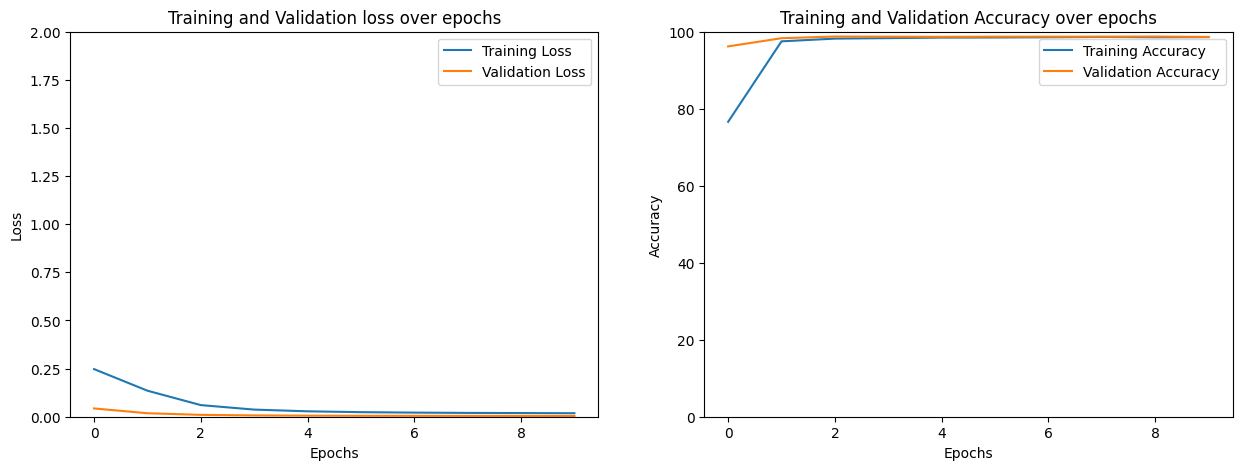

In [84]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim(0, 2)
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title("Training and Validation Accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim(0, 100)
axs[1].legend()

plt.show()